Processing: /home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/trajectory_bias_0.75.gsd
Processing: /home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/trajectory_bias_0.7727272727272727.gsd
Processing: /home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/trajectory_bias_0.7954545454545454.gsd
Processing: /home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/trajectory_bias_0.8181818181818181.gsd
Processing: /home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/trajectory_bias_0.8409090909090909.gsd
Processing: /home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/trajectory_bias_0.8636363636363636.gsd
Processing: /home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/trajectory_bias_0.886363

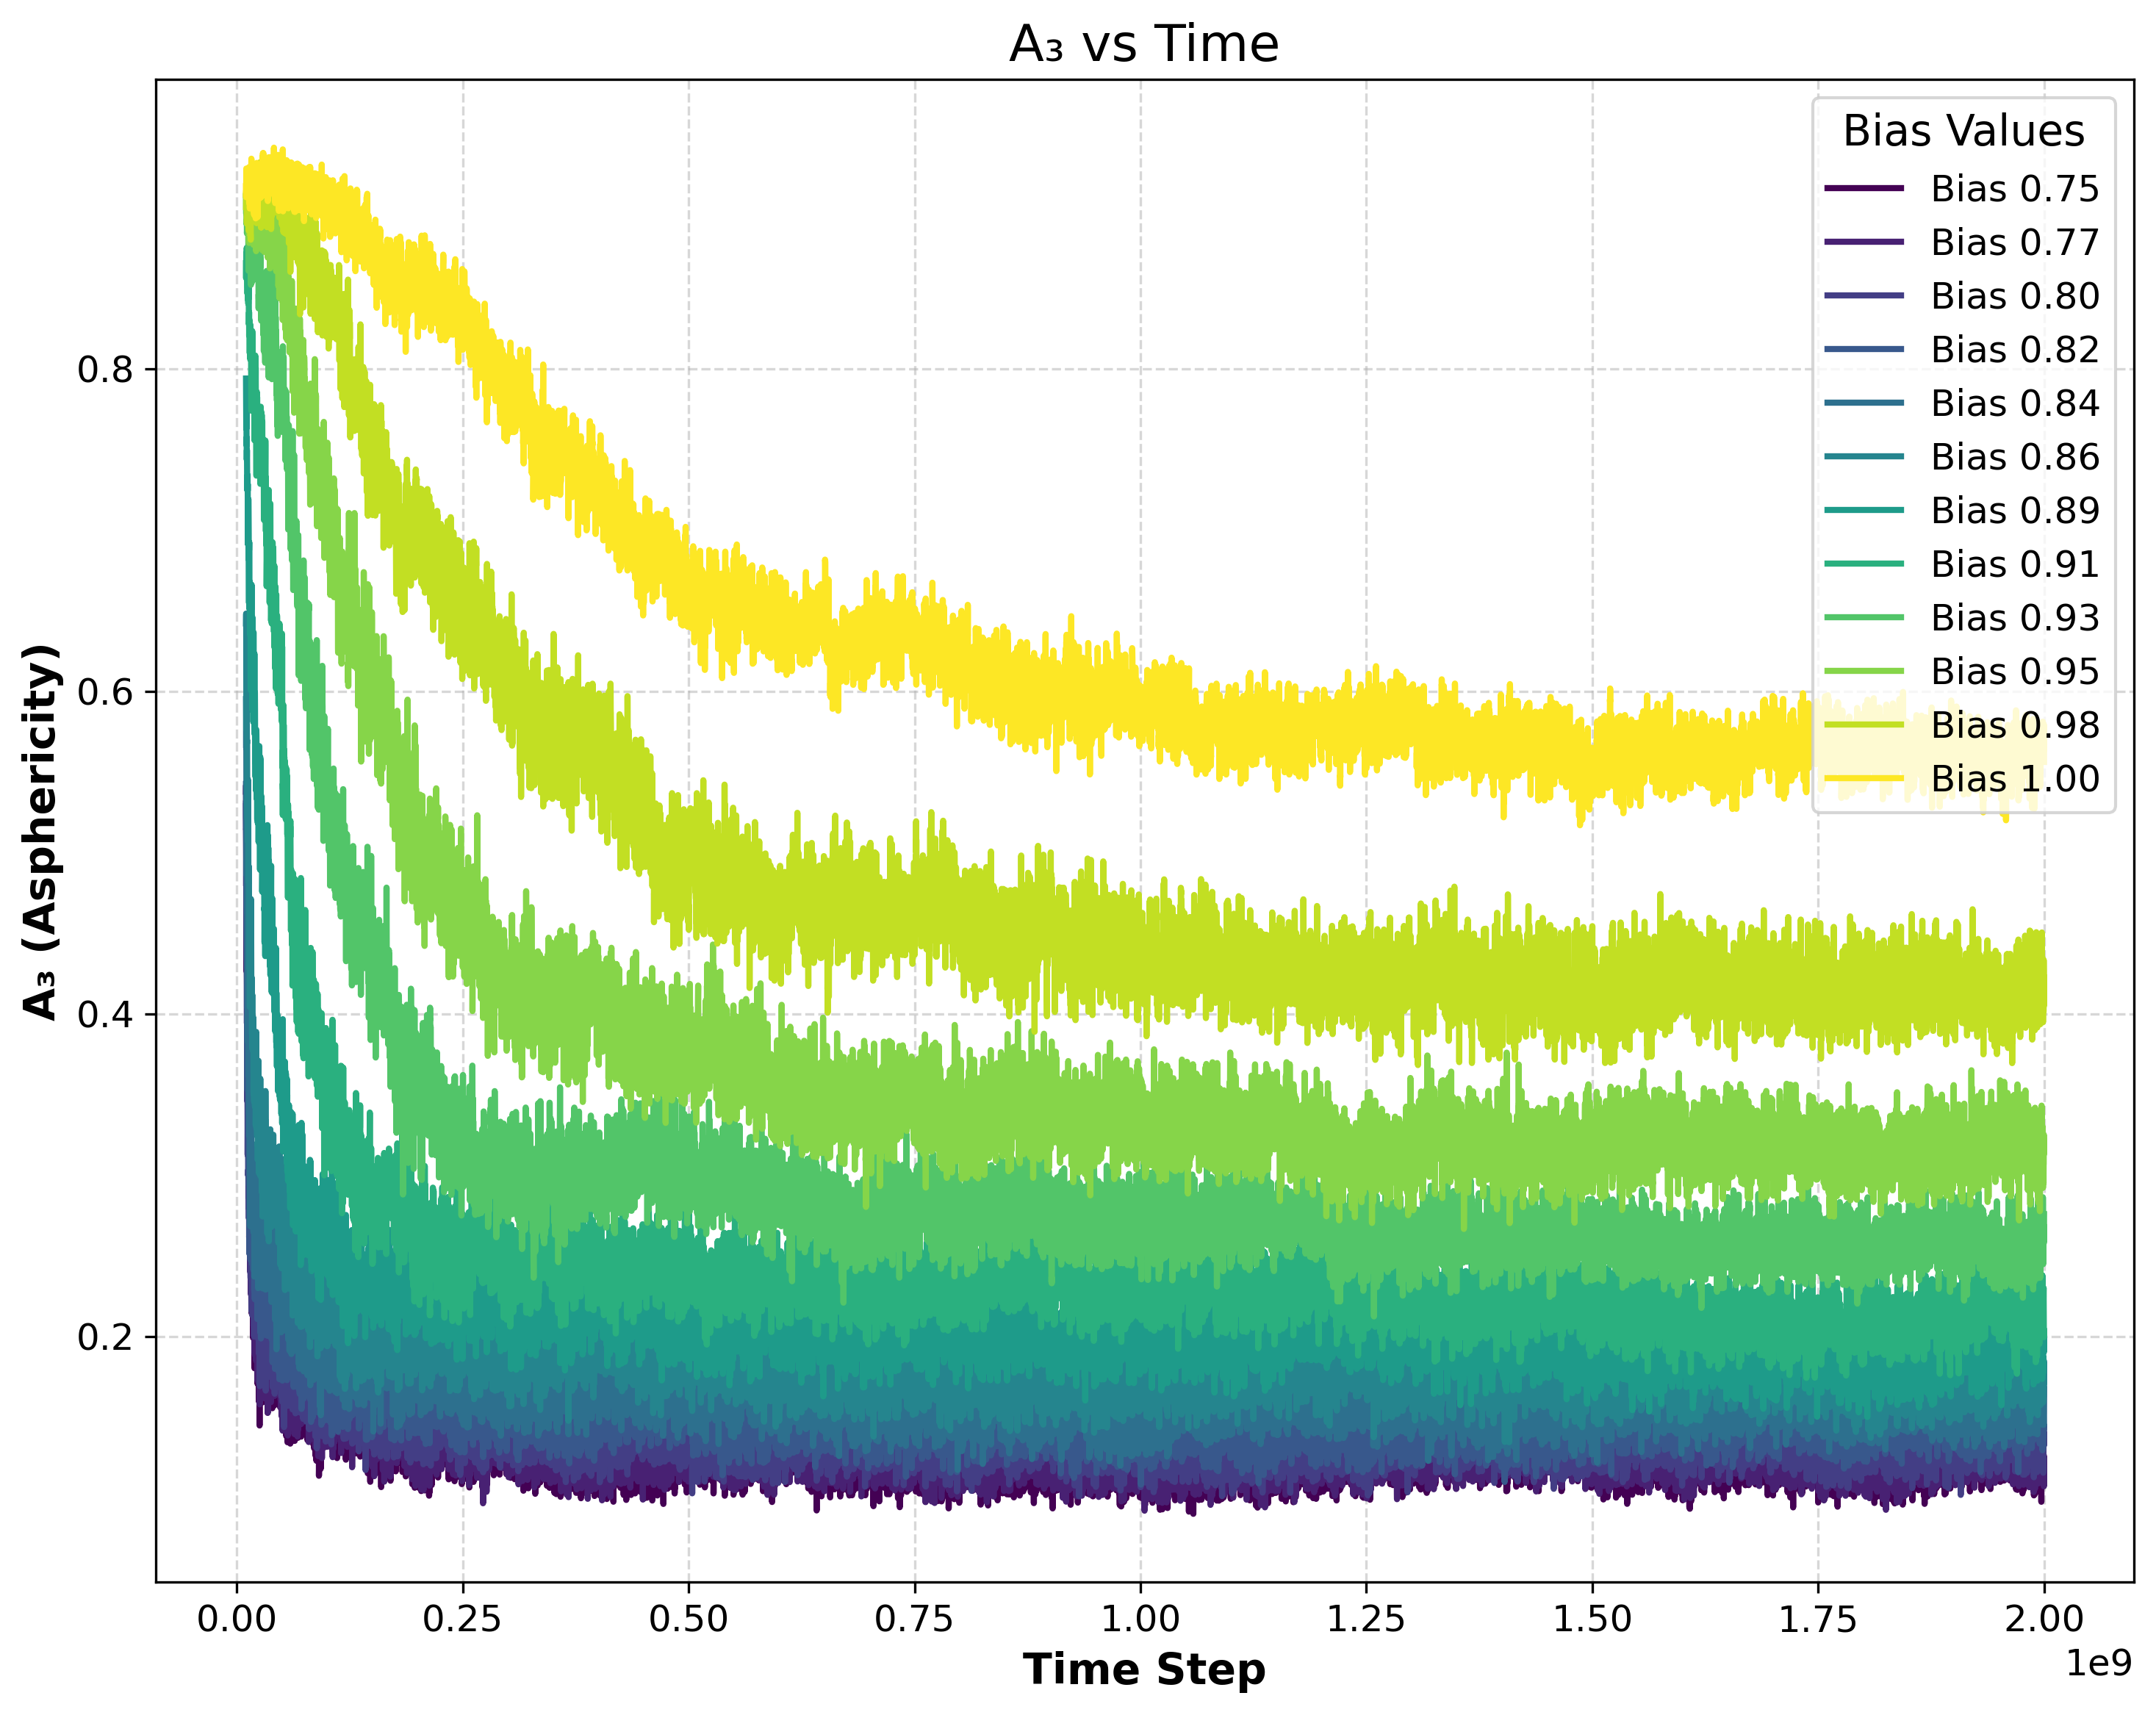

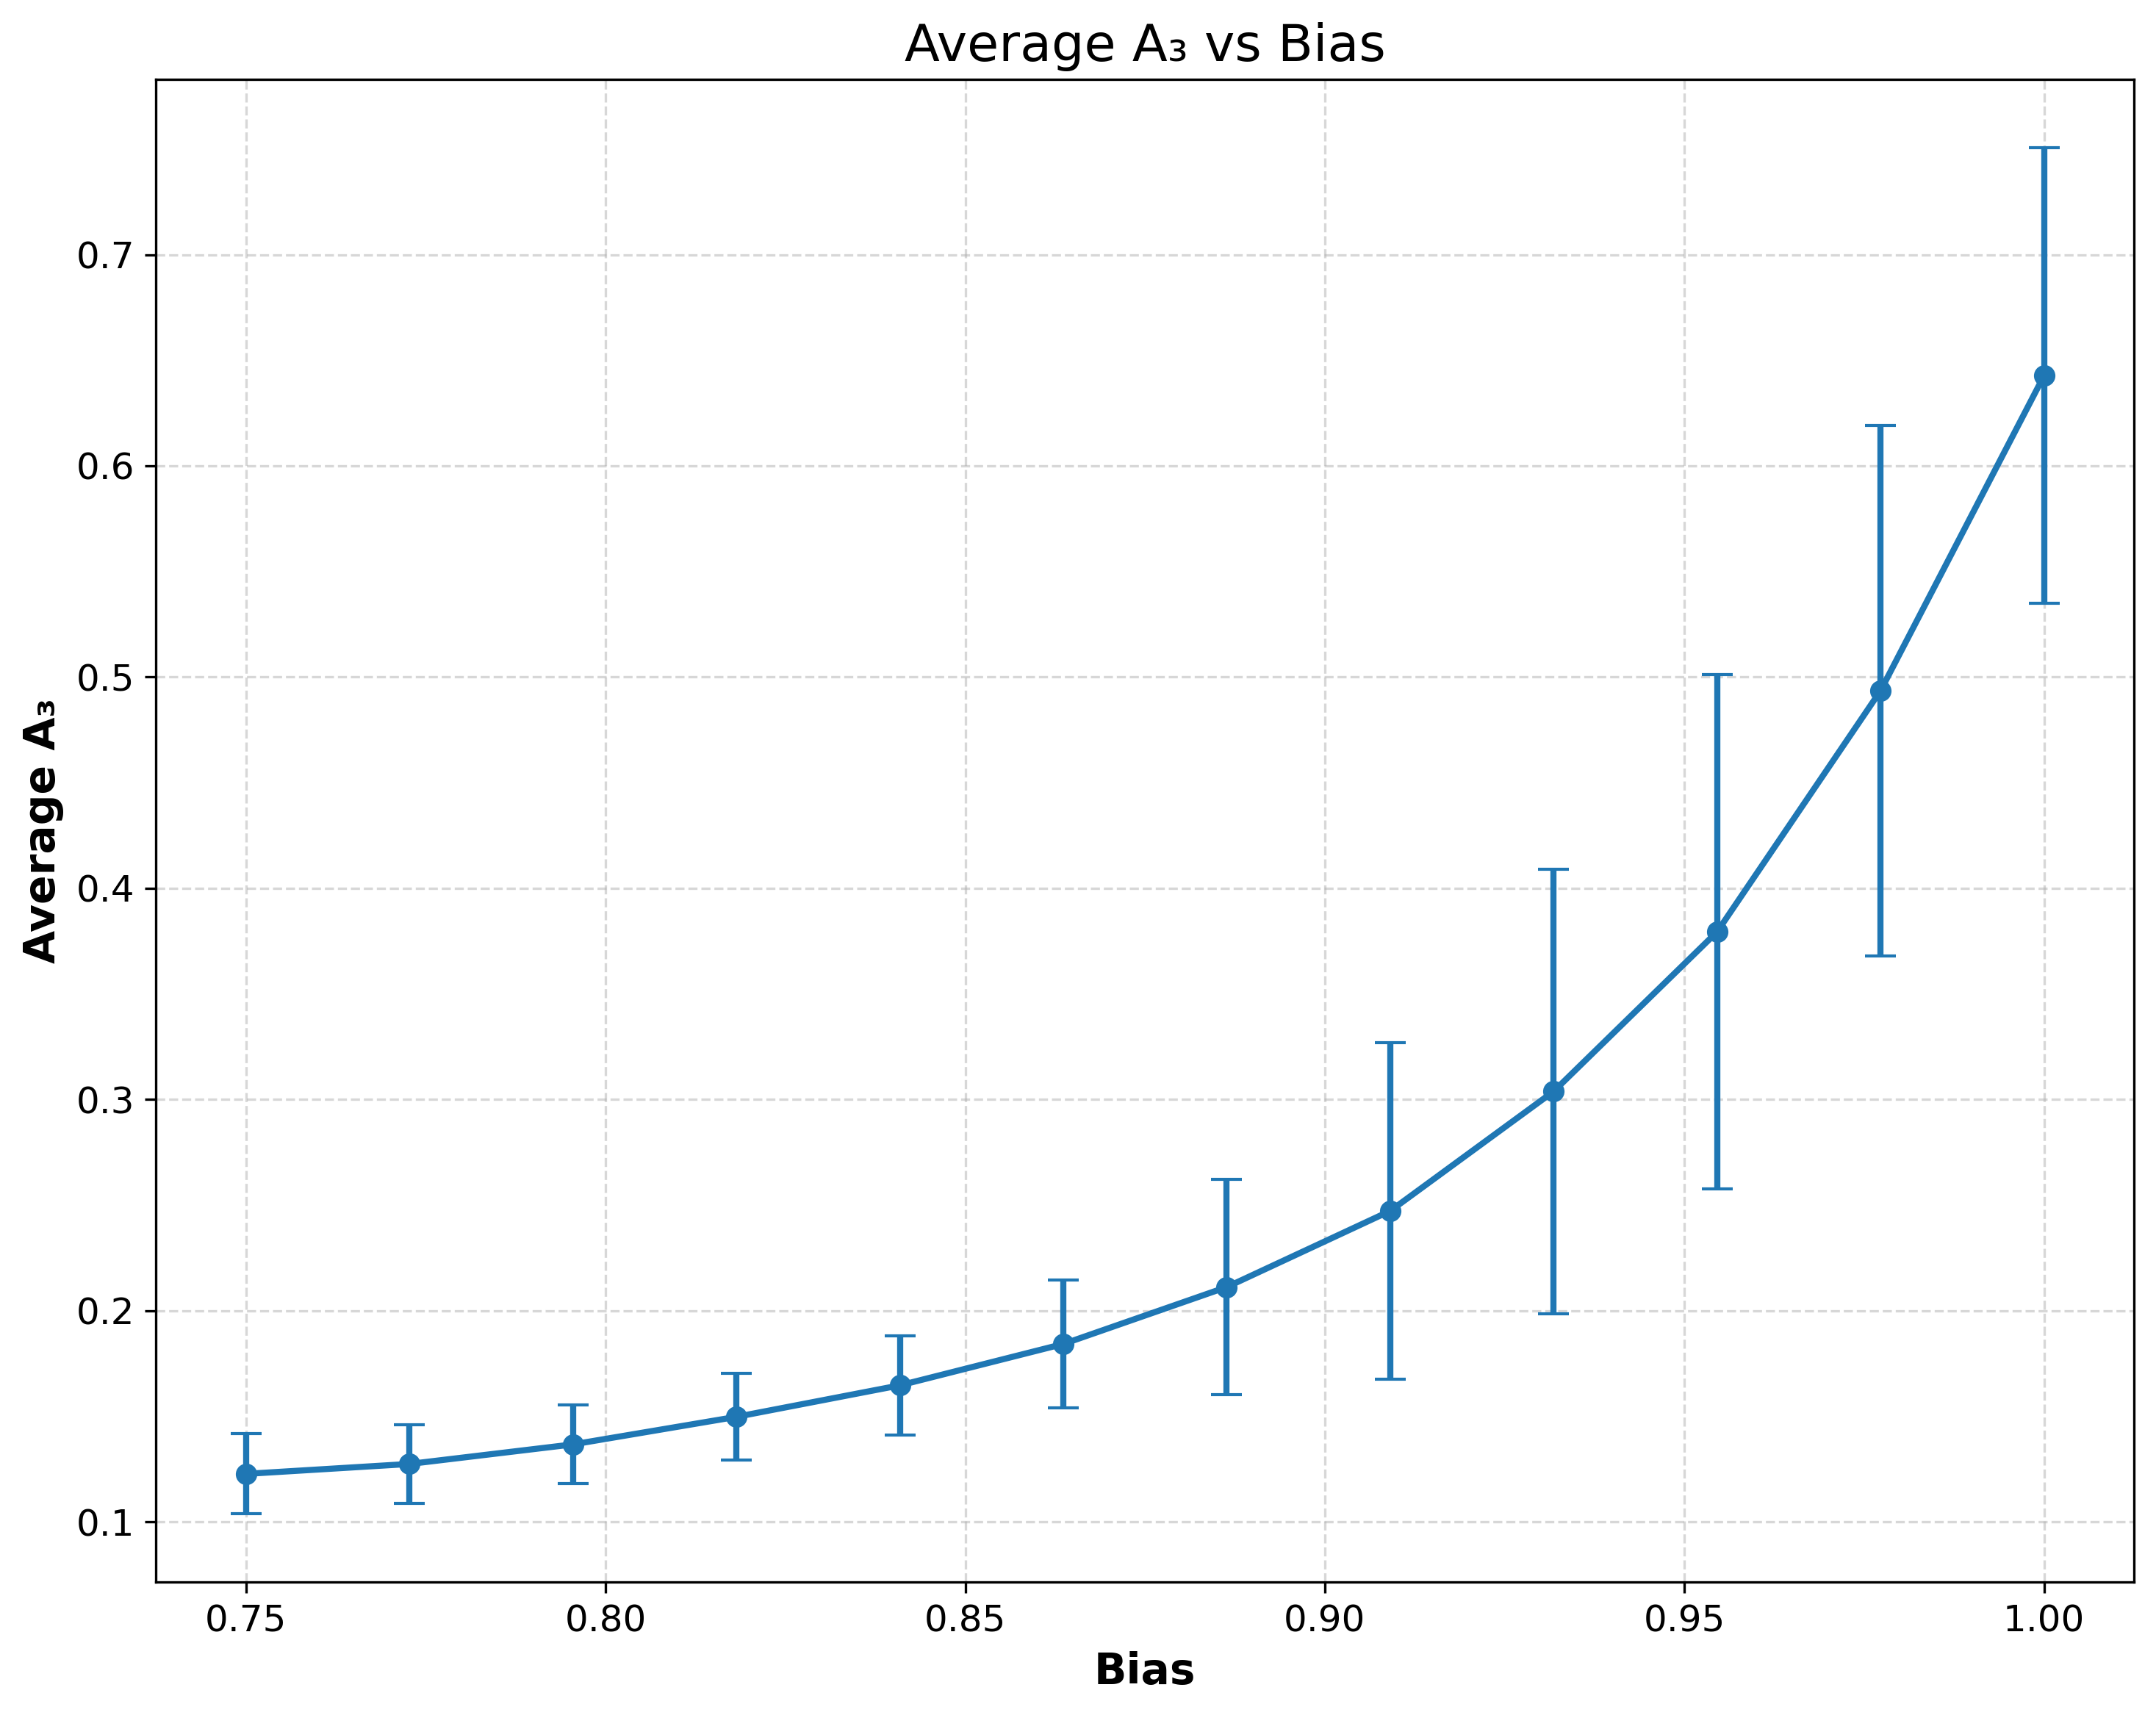

✅ Done! CSV files and plots saved: 'A3_vs_Time.csv', 'Average_A3_vs_Bias.csv', 'A3_vs_Time.png', 'Average_A3_vs_Bias.png'


In [1]:
import gsd.hoomd
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

# Set Matplotlib rcParams for nicer plots
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.labelweight': 'bold',
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (10, 8),
    'figure.dpi': 300,
})

# Apply periodic boundary conditions
def apply_pbc(positions, box):
    Lx, Ly, Lz, xy, xz, yz = box
    box_lengths = np.array([Lx, Ly, Lz])
    positions -= np.floor(positions / box_lengths) * box_lengths
    return positions

def compute_gyration_tensor(positions):
    cm = np.mean(positions, axis=0)
    rel_positions = positions - cm
    Q = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            Q[i, j] = np.mean(rel_positions[:, i] * rel_positions[:, j])
    return Q

def compute_A3(Q):
    eigenvalues = np.linalg.eigvalsh(Q)
    λ_mean = np.mean(eigenvalues)
    A3 = (1/6) * np.sum((eigenvalues - λ_mean)**2) / λ_mean**2
    return A3

# Bias values and folder
bias_values = np.linspace(0.75, 1.0, 12)
folder_path = "/home/POLY/bhandarit/Desktop/mount_viper/chain_64_01/workspace/43ef74dd463bfa6f52acb921ee73e162/"
colors = plt.cm.viridis(np.linspace(0, 1, len(bias_values)))

# Prepare figure for A3 vs time
fig_A3, ax_A3 = plt.subplots(figsize=(10, 8))

# Prepare lists for CSV data
all_time_data = []
avg_A3_per_bias = []

# Loop over biases
for idx, bias in enumerate(bias_values):
    if bias in [0.75, 1.0]:
        trajectory_name = os.path.join(folder_path, f"trajectory_bias_{bias}.gsd")
    else:
        trajectory_name = os.path.join(folder_path, f"trajectory_bias_{bias:.16f}.gsd")

    if not os.path.isfile(trajectory_name):
        print(f"File {trajectory_name} not found. Skipping.")
        continue

    print(f"Processing: {trajectory_name}")
    traj = gsd.hoomd.open(trajectory_name, 'r')

    num_chains = 64
    chain_length = len(traj[0].particles.position) // num_chains

    A3_mean_list = []
    A3_std_list = []
    time_steps = []

    for frame in traj[100:20000]:
        positions = frame.particles.position
        box = frame.configuration.box
        positions = apply_pbc(positions, box)

        A3_chain = []
        for c in range(num_chains):
            chain_positions = positions[c * chain_length:(c + 1) * chain_length]
            Q = compute_gyration_tensor(chain_positions)
            A3_chain.append(compute_A3(Q))

        A3_chain = np.array(A3_chain)
        A3_mean_list.append(np.mean(A3_chain))
        A3_std_list.append(np.std(A3_chain))
        time_steps.append(frame.configuration.step)

        all_time_data.append([bias, frame.configuration.step, np.mean(A3_chain), np.std(A3_chain)])

    # Plot A3 vs time (only mean, no STD)
    ax_A3.plot(time_steps, A3_mean_list,
               label=f'Bias {bias:.2f}', color=colors[idx], linewidth=2)

    # Average A3 across all frames for this bias
    avg_A3_per_bias.append([bias, np.mean(A3_mean_list), np.std(A3_mean_list)])

# Save CSV files
df_time = pd.DataFrame(all_time_data, columns=["Bias", "Time", "A3_mean", "A3_std"])
df_time.to_csv("A3_vs_Time.csv", index=False)

df_avg = pd.DataFrame(avg_A3_per_bias, columns=["Bias", "Average_A3_mean", "Average_A3_std"])
df_avg.to_csv("Average_A3_vs_Bias.csv", index=False)

# Finalize and save A3 vs time plot
ax_A3.set_xlabel("Time Step")
ax_A3.set_ylabel("A₃ (Asphericity)")
ax_A3.set_title("A₃ vs Time")
ax_A3.legend(title="Bias Values")
ax_A3.grid(True)
fig_A3.tight_layout()
fig_A3.savefig("A3_vs_Time.png")
plt.show()

# Plot average A3 vs bias with error bars
plt.figure(figsize=(10, 8))
plt.errorbar(df_avg["Bias"], df_avg["Average_A3_mean"], yerr=df_avg["Average_A3_std"],
             marker='o', linewidth=2, capsize=5)
plt.xlabel("Bias")
plt.ylabel("Average A₃")
plt.title("Average A₃ vs Bias")
plt.grid(True)
plt.tight_layout()
plt.savefig("Average_A3_vs_Bias.png")
plt.show()

print(" Done! CSV files and plots saved: 'A3_vs_Time.csv', 'Average_A3_vs_Bias.csv', 'A3_vs_Time.png', 'Average_A3_vs_Bias.png'")
